In [20]:
# => makes the plot interactive
%matplotlib widget
# inline makes the plots static
# %matplotlib inline 

import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
import warnings
# filter astropy warning on fits headers
warnings.filterwarnings('ignore', category=UserWarning, append=True)
from spectro_tools import *
import glob # helps with building file lists
from pathlib import Path # to set the path
from numpy.polynomial import chebyshev
from numpy.polynomial import polynomial
import re
%load_ext autoreload
%autoreload 2

# Just like we did for image reduction, reducing spectra involves:
# 1 - generate master_bias = median(bias)
# 2 - generate master_flat = median(normalized (flat-master_bias))
# 3 - reduced_spectrum = (raw_spectrum - master_bias)/master_flat
# and we'll stop here, as:
# 4 - the last step is the wavelength calibration, and is done in a different notebook


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# 1. Define your base data directory, the path where the data is
data_dir = Path("../../data/t152_spectro/") 

# 2. Set up subdirectories for raw science data, biases, flats and reduced data
raw_dir = data_dir / "M1"
bias_dir = data_dir / "offsets"
flat_dir = data_dir / "flats"
lamp_dir = data_dir / "lamp_thar"
output_dir = data_dir / "REDUCED"

# 3. Create the output folder automatically if it doesn't exist
output_dir.mkdir(parents=True, exist_ok=True)

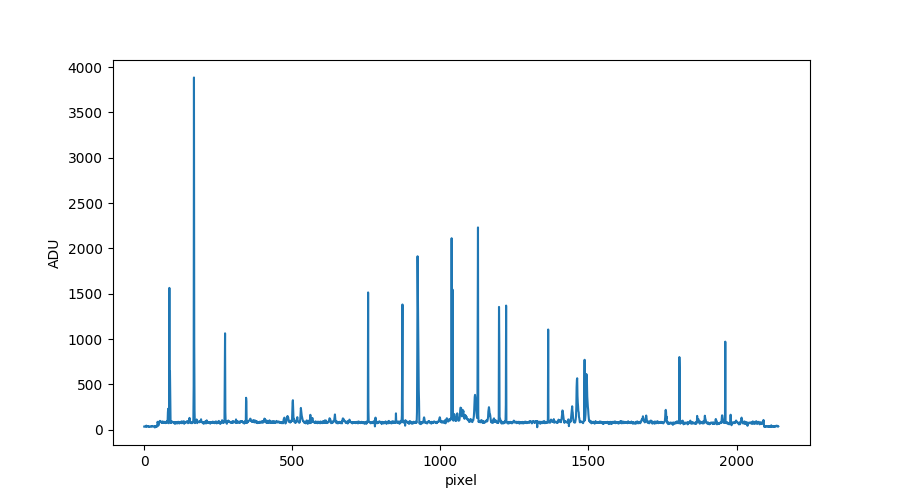

In [3]:
# First lets have a look at a raw spectrum:
#files=glob.glob('../../data/2023/t152_spectro/NGC40/NGC*.fits')
# 
files = list(raw_dir.glob("*.fits")) 
xaxis,data=read_raw_spectrum(files[0])
plt.figure(figsize=(9, 5))
plt.plot(data)
plt.xlabel('pixel')
plt.ylabel('ADU')
plt.show()

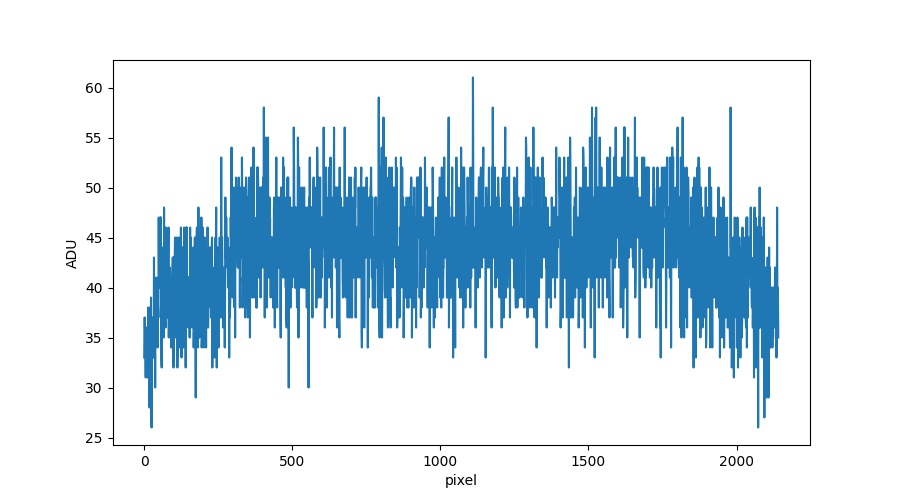

In [4]:
# Now, let's have a look at a bias:
# This is another way... 
# files=glob.glob('../../data/2023/t152_spectro/calibrations_1er-groupe/bias_00009.fits')
files = list(bias_dir.glob("*.fits")) 

xaxis,data=read_raw_spectrum(files[0])
plt.figure(figsize=(9, 5))
plt.plot(data)
plt.xlabel('pixel')
plt.ylabel('ADU')
plt.show()

In [5]:
# this is a just a read-write consistency test
xaxis,data,header=read_raw_spectrum(files[0],get_header=1)
print(data)
write_fits_spectrum('test.fits',data,header=header)
xaxis,data1,header=read_raw_spectrum('test.fits',get_header=1)
print(data1)


[33 37 37 ... 40 39 35]
wrote  test.fits
[33 37 37 ... 40 39 35]


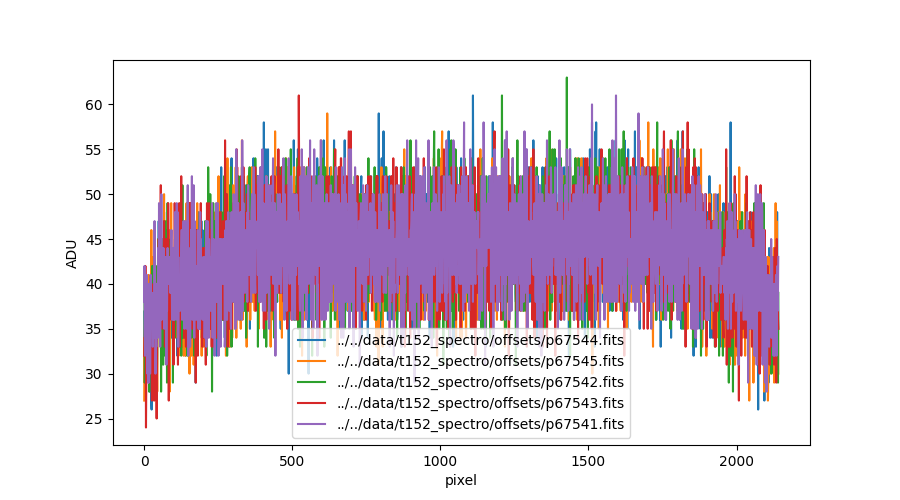

In [6]:
# Now, let's overplot them, just out of curiosity
files = list(bias_dir.glob("*.fits")) 

plt.figure(figsize=(9, 5))

for file in files:
    xaxis,data=read_raw_spectrum(file)
    plt.plot(data,label=file)
plt.legend()
plt.xlabel('pixel')
plt.ylabel('ADU')
plt.show()

In [7]:
# EXERCISE:
# and now let's median them like we did for the image bias:
files = list(bias_dir.glob("*.fits")) 

nfiles=len(files)
# read first file to get length of spectrum
xaxis,data=read_raw_spectrum(files[0])
npix=len(data)
print(npix)
data_array=np.zeros((npix,nfiles))
i=0
for file in files:
    xaxis,data,header=read_raw_spectrum(file,get_header=1)
    data_array[:,i]=data
    i=i+1

master_bias=np.median(data_array,axis=1)

master_bias_file = output_dir / "master_bias.fits"

write_fits_spectrum(master_bias_file,master_bias,header=header)


2142
wrote  ../../data/t152_spectro/REDUCED/master_bias.fits


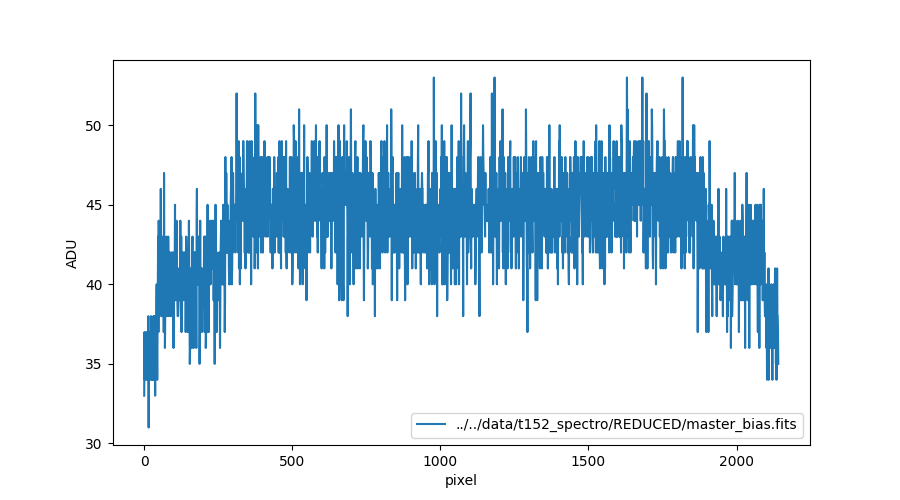

In [8]:
master_bias_file = output_dir / "master_bias.fits"
xaxis,data=read_raw_spectrum(master_bias_file)

plt.figure(figsize=(9, 5))
plt.plot(data,label=master_bias_file)
plt.legend()
plt.xlabel('pixel')
plt.ylabel('ADU')
plt.show()

In [ ]:
# 1. Sanity-check master_bias itself, before writing
#print('master_bias shape (in memory):', master_bias.shape)

# 2. Write it
#write_fits_spectrum(master_bias_file, master_bias, header=header)

# 3. Read the raw FITS structure directly, bypassing read_raw_spectrum entirely
#from astropy.io import fits
#with fits.open(master_bias_file) as hdul:
#    hdul.info()
#    print('raw written shape:', hdul[0].data.shape)

In [12]:
print('Did we improve the statistics?')

# read the master and the biases 
files = list(bias_dir.glob("*.fits")) 

print('==============================')
for file in files:
    xaxis,data=read_raw_spectrum(file)
    print(np.mean(data),np.std(data))

print('==============================')
print('Master Bias')
print(np.mean(master_bias),np.std(master_bias))


Did we improve the statistics?
43.73389355742297 5.046391659438788
43.49906629318394 4.954107696491301
43.739495798319325 5.048626231290878
43.61017740429505 4.972543574910335
43.788982259570496 5.000682492231166
Master Bias
43.74089635854342 3.24182498940039


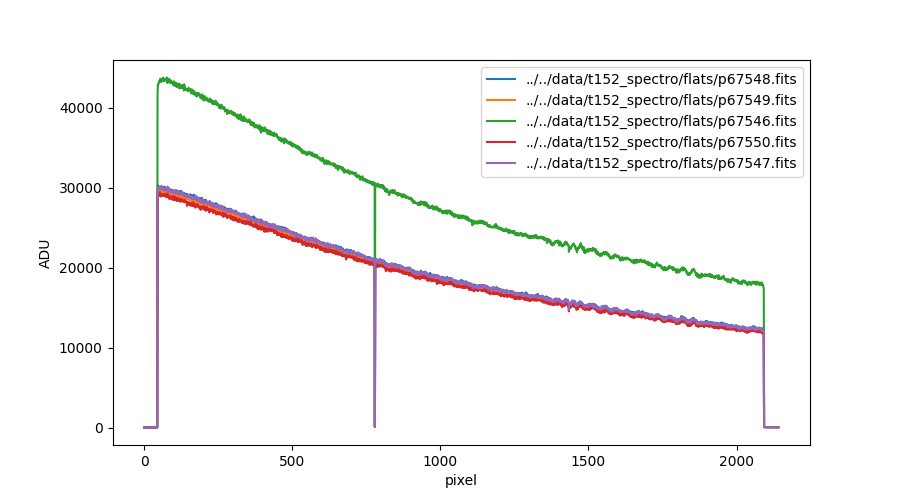

In [13]:
# lets look at the flats:
files = list(flat_dir.glob("*.fits")) 

plt.figure(figsize=(9, 5))

for file in files:
    xaxis,data=read_raw_spectrum(file)
    plt.plot(data,label=file)
plt.legend()
plt.xlabel('pixel')
plt.ylabel('ADU')
plt.show()

# If there are a weird ones, clean / select the ones you would like to use.

# What is the origin of the wide negative slope we see there?
# maybe have a look at the header for a clue?

If only a subset of flats look ok, identify and remove the bad ones before continuing. 



In [46]:
# We'd like to remove that slope because it is not useful in our analysis. 
# Because its actually an artefact of our flatfielding apparatus.
# Maybe we can try fitting it with a low order polynomial and dividing the flat by that:
# But FIRST we MUST remove the bias, before doing anything else!
files = list(flat_dir.glob("*.fits")) 

# set the master_bias file and read it
master_bias_file = output_dir / "master_bias.fits"
xaxis,master_bias=read_raw_spectrum(master_bias_file)

# remove master_bias
for file in files: 
    xaxis,data=read_raw_spectrum(file)
    data=data-master_bias
    base_name = file.stem+'_flatcorr.fits'
    file_name = output_dir / base_name
    write_fits_spectrum(file_name,data,header=header)


wrote  ../../data/t152_spectro/REDUCED/p67548_flatcorr.fits
wrote  ../../data/t152_spectro/REDUCED/p67549_flatcorr.fits
wrote  ../../data/t152_spectro/REDUCED/p67546_flatcorr.fits
wrote  ../../data/t152_spectro/REDUCED/p67550_flatcorr.fits
wrote  ../../data/t152_spectro/REDUCED/p67547_flatcorr.fits


[ 2.47582513e+04 -2.09499278e+00 -1.31903587e-03]


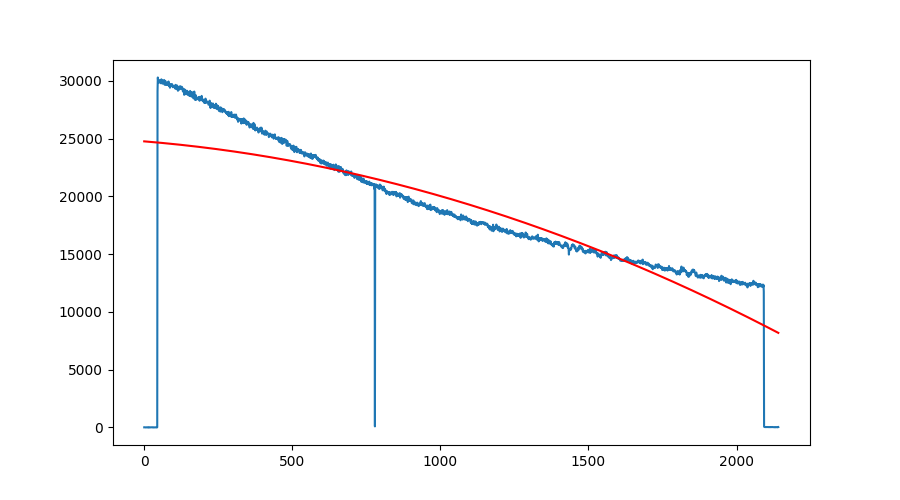

In [48]:
# now lets try to fit the flat with that chebyshev poly:
# Fit a polynomial of degree 3 or whatever it looks like it should be
# degree = 3
# coeffs = polynomial.polyfit(xaxis, data, degree)
# Fit a Chebyshev polynomial 
files = list(output_dir.glob("*_flatcorr.fits")) 
xaxis,data=read_raw_spectrum(files[0])

degree = 2
coeffs = chebyshev.chebfit(xaxis, data, degree)
print(coeffs)
# Evaluate the Chebyshev polynomial at the x_range
# y_fit = polynomial.polyval(xaxis, coeffs)
y_fit = chebyshev.chebval(xaxis, coeffs)
plt.figure(figsize=(9,5))
plt.plot(xaxis,data,label=file)
plt.plot(xaxis, y_fit, label=f'Chebyshev Polynomial (Degree {degree})', color='red')
plt.show()


[ 3.12963883e+04 -1.62284557e+01  2.08327505e-03 -8.84162885e-08]


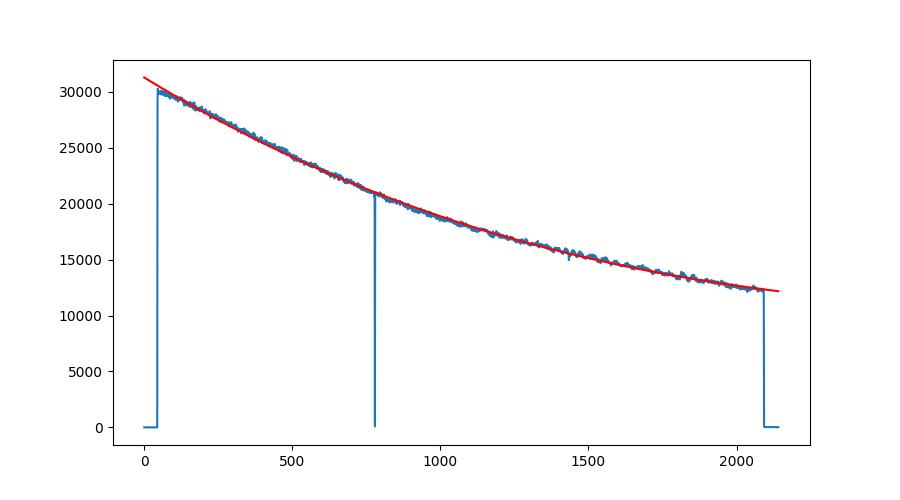

In [49]:
# in case of outliers!! 0 = false / ignore; 1 = true / perform
if(1):

    # mask the outliers:
    weights=np.full(len(xaxis),1.)
    ind=np.where(data/np.median(data)<=0.25)[0]
    weights[ind]=0.

    #redo the fit using those weights:
    # Fit a Chebyshev polynomial of degree 3
    degree = 3
    # now lets try to fit the flat with that chebyshev poly:
    coeffs = chebyshev.chebfit(xaxis, data, degree,w=weights)
    print(coeffs)
    # Evaluate the Chebyshev polynomial at the x_range
    y_fit = chebyshev.chebval(xaxis, coeffs)
    
    plt.figure(figsize=(9,5))
    plt.plot(xaxis,data,label=file)
    plt.plot(xaxis, y_fit, label=f'Chebyshev Polynomial (Degree {degree})', color='red')
    plt.show()

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                  -64 / array data type                                NAXIS   =                    3 / number of array dimensions                     NAXIS1  =                 2142                                                  NAXIS2  =                    1                                                  NAXIS3  =                    1                                                  DATE    ='2007-02-20'          /                                                DATE-OBS='2007-02-20'          /                                                OBJECT  ='Tungstene          ' /                                                TM-START=                70123 /                                                TM-EXPOS=                    3 /                                                J_D     =        2454152.31161 /                                                POSTN-RA=               0.0000 /        

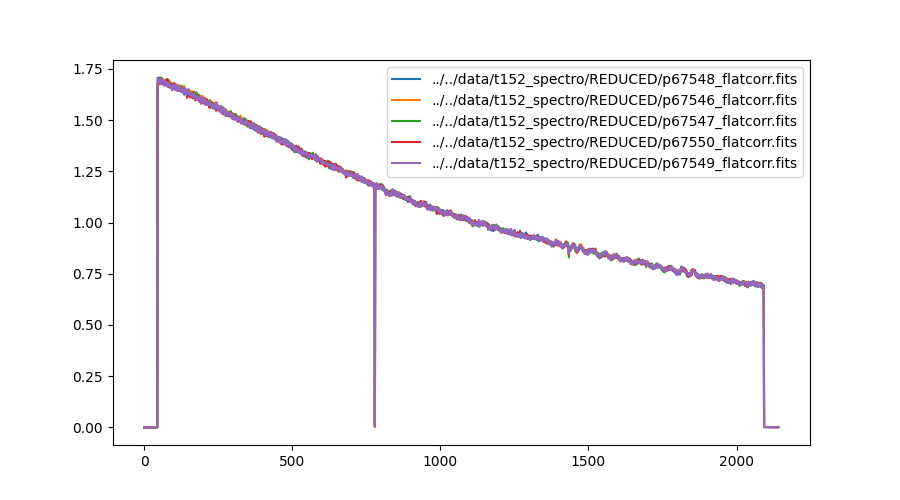

In [50]:
# lets normalize them to make sure they line up before medianning:
files = list(output_dir.glob("*_flatcorr.fits")) 

plt.figure(figsize=(9, 5))


for file in files:
    xaxis,data,header=read_raw_spectrum(file,get_header=1)
    print(header)
    normdata=data/np.median(data)
    plt.plot(normdata,label=file)
    base_name = file.stem+'_flatnorm.fits'
    target_file = output_dir / base_name
    write_fits_spectrum(target_file,normdata,header=header)
plt.legend()
plt.show()


[PosixPath('../../data/t152_spectro/REDUCED/p67550_flatnorm.fits'), PosixPath('../../data/t152_spectro/REDUCED/p67547_flatnorm.fits'), PosixPath('../../data/t152_spectro/REDUCED/p67550_flatcorr_flatnorm.fits'), PosixPath('../../data/t152_spectro/REDUCED/p67549_flatnorm.fits'), PosixPath('../../data/t152_spectro/REDUCED/p67548_flatnorm.fits'), PosixPath('../../data/t152_spectro/REDUCED/p67549_flatcorr_flatnorm.fits'), PosixPath('../../data/t152_spectro/REDUCED/p67547_flatcorr_flatnorm.fits'), PosixPath('../../data/t152_spectro/REDUCED/p67546_flatcorr_flatnorm.fits'), PosixPath('../../data/t152_spectro/REDUCED/p67546_flatnorm.fits'), PosixPath('../../data/t152_spectro/REDUCED/p67548_flatcorr_flatnorm.fits')]


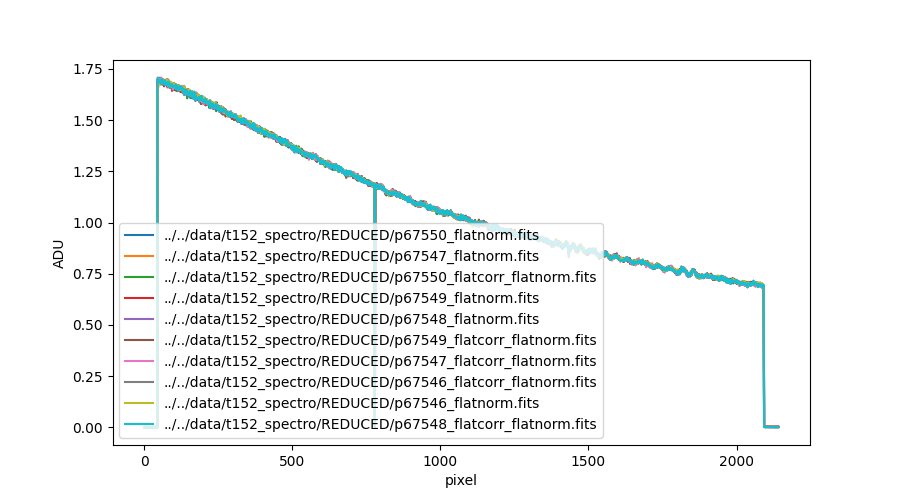

In [51]:
# now plot the normalized flats:
# lets look at the flats:
files = list(output_dir.glob("*_flatnorm.fits")) 
print(files)
plt.figure(figsize=(9, 5))

for file in files:
    xaxis,data,header=read_raw_spectrum(file,get_header=1)
    plt.plot(data,label=file)

plt.legend()
plt.xlabel('pixel')
plt.ylabel('ADU')
plt.show()

[PosixPath('../../data/t152_spectro/REDUCED/p67550_flatnorm.fits'), PosixPath('../../data/t152_spectro/REDUCED/p67547_flatnorm.fits'), PosixPath('../../data/t152_spectro/REDUCED/p67550_flatcorr_flatnorm.fits'), PosixPath('../../data/t152_spectro/REDUCED/p67549_flatnorm.fits'), PosixPath('../../data/t152_spectro/REDUCED/p67548_flatnorm.fits'), PosixPath('../../data/t152_spectro/REDUCED/p67549_flatcorr_flatnorm.fits'), PosixPath('../../data/t152_spectro/REDUCED/p67547_flatcorr_flatnorm.fits'), PosixPath('../../data/t152_spectro/REDUCED/p67546_flatcorr_flatnorm.fits'), PosixPath('../../data/t152_spectro/REDUCED/p67546_flatnorm.fits'), PosixPath('../../data/t152_spectro/REDUCED/p67548_flatcorr_flatnorm.fits')]
[ 1.76527848e+00 -9.13754479e-04  1.16603688e-07 -4.84034669e-12]


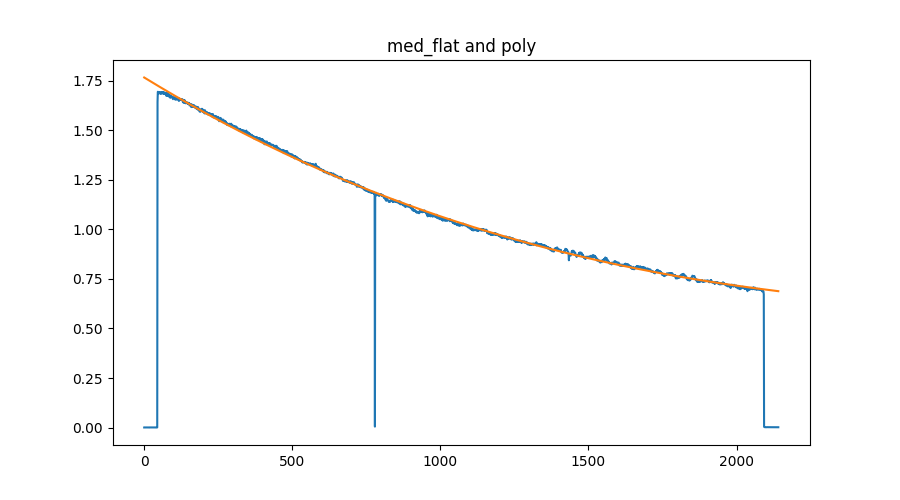

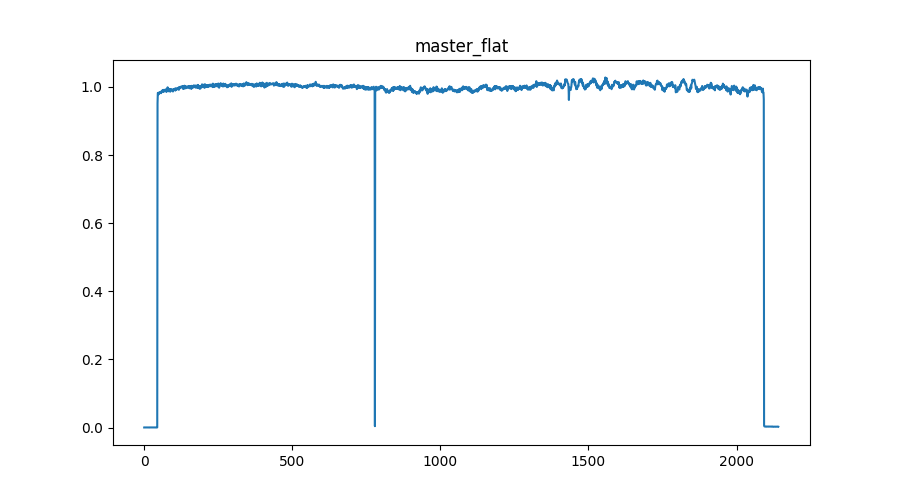

wrote  ../../data/t152_spectro/REDUCED/master_flat.fits


In [55]:
# same to remove the outliers
if(1):
    # Now we want to:
    # 1 - median them together to improve the S/N ratio
    # 2 - remove the slope
    # 3 - that is our master_flat that we save

    # 1 medianning:
    files = list(output_dir.glob("*flatnorm.fits")) 

    print(files)
    # read 1 file to get length of spectrum
    axis,data,header=read_raw_spectrum(files[0],get_header=1)
    npix=len(data)
    nfiles=len(files)
    data_array=np.zeros((npix,nfiles))
    i=0
    for i in range(0,nfiles):
        axis,data=read_raw_spectrum(files[i])
        data_array[:,i]=data

    med_flat=np.median(data_array,axis=1)

    # 2 - remove the slope:
    # mask the outliers:
    weights=np.full(len(xaxis),1.)
    ind=np.where(data/np.median(data)<=0.25)[0]
    weights[ind]=0.

    # Fit a Chebyshev polynomial of degree 3
    degree = 3
    # now lets try to fit the flat with that chebyshev poly:
    coeffs = chebyshev.chebfit(xaxis, med_flat, degree, w=weights)
    print(coeffs)
    # Evaluate the Chebyshev polynomial at the x_range
    y_fit = chebyshev.chebval(xaxis, coeffs)

    master_flat=med_flat/y_fit

    plt.figure(figsize=(9,5))
    plt.plot(med_flat)
    plt.plot(y_fit)
    plt.title('med_flat and poly')
    plt.show()

plt.figure(figsize=(9,5))
plt.plot(master_flat)
plt.title('master_flat')
plt.show()

master_flat_file = output_dir / "master_flat.fits"

write_fits_spectrum(master_flat_file,master_flat,header=header)

    

In [61]:
# Now we can reduce an observed spectrum:

obsfiles = list(raw_dir.glob("*.fits")) 
 
master_biasfile = output_dir / "master_bias.fits"
master_flatfile = output_dir / "master_flat.fits"  

axis,obs,header=read_raw_spectrum(obsfiles[0],get_header=1)
axis,master_bias=read_raw_spectrum(master_biasfile)
axis,master_flat=read_raw_spectrum(master_flatfile)

reduced=(obs-master_bias)/master_flat

base_name = obsfiles[0].stem
filename = output_dir / (base_name + "_reduced.fits")
write_fits_spectrum(filename, reduced, header=header)


wrote  ../../data/t152_spectro/REDUCED/p67555_reduced.fits


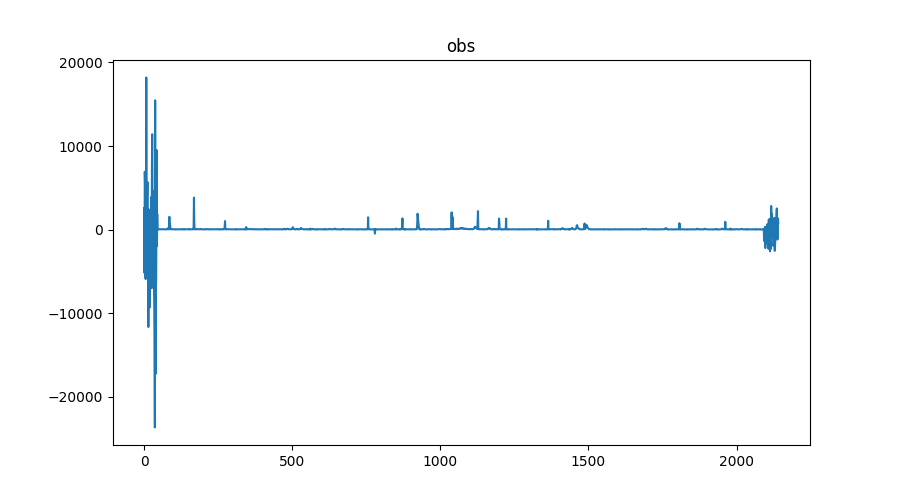

In [62]:
axis,obs,header=read_raw_spectrum(filename,get_header=1)
plt.figure(figsize=(9,5))
plt.plot(obs)
plt.title('obs')
plt.show()

In [52]:
filename = "../../data/2023/t152_spectro/NGC40/NGC40_00001.fits"
# The spectrum is in the second HDU of this file.
with fits.open(filename) as f:
    specdata = f[0].data

In [ ]:
# Now calibration is somewhere else 